<center>
    <img src="https://rockborne.com/wp-content/uploads/2021/07/LandingPage-Header-RED-CENTRE.jpg" width="900" alt="logo"  />
</center>

# Practical: Data Preprocessing Case Study

*Session 5 · Notebook 01.04 · Practical · Coach version · Databricks (no extra installs)*

## About this notebook

This is a hands-on **mini-project**, a real case study handed to you much as it would arrive in practice. The case study text, data description and task list below are taken from the original brief; the working sections after them walk you through completing each part of the task, pulling together the preprocessing skills from the lecture (notebook 01.03).

## About the exercises

Each task appears as three cells:

1. A markdown cell describing what to do (sometimes with a `> *Hint:*`).
2. A `# Your turn` cell for you to write your answer.
3. A `# Coach answer` cell with worked, runnable code.

Work top to bottom: later tasks reuse variables from earlier answers, so run every cell as you go.

## The case study

You have been presented with a dataset containing visceral adipose tissue measurements taken during pregnancy. This dataset ([available on PhysioNet](https://physionet.org/content/maternal-visceral-adipose/1.0.0/)) comes from a cohort study of pregnant women up to 20 weeks of pregnancy, followed until delivery. Measurement of maternal visceral adipose tissue (VAT) was performed during a routine obstetric ultrasound. At the same time, a biometric evaluation was carried out and information was obtained from prenatal care. Gestational outcomes, including gestational diabetes mellitus (GDM), were obtained by evaluating the patients' medical records at the hospitals where the births took place. The data was collected as part of a study that sought to evaluate whether maternal VAT could predict GDM at the time of delivery.

The variables in the dataset include maternal age, previous diabetes, blood pressure (on the same day as the VAT measurement), VAT (in the periumbilical region), gestational age at inclusion, number of pregnancies, first fasting glucose level and pre-gestational body mass index (BMI). It also records the pregnancy outcomes: gestational age at birth, type of delivery (vaginal or caesarean section), child birth weight, and the diagnosis of GDM.

The study sample consisted of a cohort of 154 women recruited between October 2016 and December 2017 at the Ultrasound Department of the Murialdo Teaching Health Center in Porto Alegre, Brazil. Participants were followed until delivery. Of the 154 women selected initially, 21 (13%) were lost to follow-up, giving a final sample of 133 women. The inclusion criteria were a singleton pregnancy and a gestational age of 20 weeks or less. The exclusion criterion was pre-existing type 1 or type 2 diabetes mellitus.

## Data description

The intake data (first 20 weeks of pregnancy) and the delivery outcomes (gestational diabetes, type of delivery, newborn weight and gestational age) are recorded in `visceral_fat.csv`. The variables are:

1. **number:** unique ID for the case.
2. **age (years):** age in years.
3. **ethnicity:** ethnicity (0 = white, 1 = not white).
4. **diabetes mellitus:** previous diabetes mellitus (0 = no, 1 = yes).
5. **mean diastolic bp (mmhg):** mean diastolic blood pressure in mmHg.
6. **mean systolic bp (mmhg):** mean systolic blood pressure in mmHg.
7. **central armellini fat (mm):** maternal visceral adipose tissue measurement in mm.
8. **current gestational age:** gestational age at inclusion (weeks, days of pregnancy).
9. **pregnancies (number):** number of pregnancies.
10. **first fasting glucose (mg/dl):** first measured fasting glucose.
11. **bmi pregestational (kg/m):** pre-gestational body mass index.
12. **gestational age at birth:** gestational age at birth (weeks, days of pregnancy).
13. **type of delivery:** 0 = vaginal birth, 1 = caesarean section.
14. **child birth weight (g):** birth weight in grams.
15. **gestational dm:** current gestational diabetes (0 = no, 1 = yes). This is the target.

Missing data is indicated by an empty cell.

## Your task

Your task is to **clean and prepare the data for further analysis**. The brief suggests the following steps:

1. Perform an initial data assessment and check what kind of issues the data presents.
2. Handle the missing data: some models require complete data, so evaluate and analyse the impact of the different strategies for dealing with missing values.
3. Consider whether the data needs enrichment by creating calculated fields (for example, [pulse pressure](https://health.selfdecode.com/blog/pulse-pressure/)).
4. Given that the data is highly imbalanced in terms of women who develop gestational diabetes, propose and apply ways to balance it.
5. Apply normalization/standardization to the data.

The sections below work through each of these tasks in turn.

## Index

0. [Setup](#setup)
1. [Task 1: Initial data assessment](#task1)
2. [Task 2: Handling missing data](#task2)
3. [Task 3: Data enrichment and feature preparation](#task3)
4. [Task 4: Handling the imbalanced target](#task4)
5. [Task 5: Normalization and standardization](#task5)
6. [Wrap-up](#wrap)

<a id="setup"></a>
## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# imbalanced-learn is not needed: these helpers reproduce RandomOverSampler / RandomUnderSampler
# with only scikit-learn, so this notebook runs on a plain Databricks cluster (no extra installs).
def random_oversample(X, y, random_state=0):
    """Oversample minority class(es) up to the majority count."""
    X_arr, y_arr = np.asarray(X), np.asarray(y)
    counts = pd.Series(y_arr).value_counts()
    n_max = int(counts.max())
    px, py = [], []
    for cls in counts.index:
        idx = np.where(y_arr == cls)[0]
        keep = resample(idx, replace=True, n_samples=n_max, random_state=random_state)
        px.append(X_arr[keep]); py.append(y_arr[keep])
    Xr, yr = np.vstack(px), np.concatenate(py)
    order = resample(np.arange(len(yr)), replace=False, n_samples=len(yr), random_state=random_state)
    return Xr[order], yr[order]


def random_undersample(X, y, random_state=0):
    """Undersample majority class(es) down to the minority count."""
    X_arr, y_arr = np.asarray(X), np.asarray(y)
    counts = pd.Series(y_arr).value_counts()
    n_min = int(counts.min())
    px, py = [], []
    for cls in counts.index:
        idx = np.where(y_arr == cls)[0]
        keep = resample(idx, replace=False, n_samples=n_min, random_state=random_state)
        px.append(X_arr[keep]); py.append(y_arr[keep])
    Xr, yr = np.vstack(px), np.concatenate(py)
    order = resample(np.arange(len(yr)), replace=False, n_samples=len(yr), random_state=random_state)
    return Xr[order], yr[order]


print("Setup complete.")

<a id="task1"></a>
## Task 1: Initial data assessment

Before changing anything, understand what you have. Never clean blind.

### Exercise 1: Load and take a first look

Read `../../datasets/visceral_fat.csv` into a DataFrame called `df`. Show its shape, `df.head()`, and `df.info()`. Note which columns are numeric and which came in as `object` (text).

In [2]:
# Your turn


In [3]:
# Coach answer
# Or read directly from the public S3 bucket (no local file needed):
# df = pd.read_csv("https://rockborne-bucket-01-cbs.s3.eu-west-2.amazonaws.com/Data_Sources_CBS_Risk/Session_5/visceral_fat.csv")
# Or from S3 with Spark, then to pandas (needs a SparkSession, e.g. on Databricks):
# df = spark.read.csv("s3://rockborne-bucket-01-cbs/Data_Sources_CBS_Risk/Session_5/visceral_fat.csv", header=True, inferSchema=True).toPandas()
# ...or read the paths from a config file (the local read below stays the default):
# from config import session_datasets
# df = spark.read.csv(session_datasets["visceral_fat"], header=True, inferSchema=True).toPandas()
df = pd.read_csv("../../datasets/Session_5/visceral_fat.csv")
print("Shape:", df.shape)
display(df.head())
df.info()

Shape: (133, 15)


,number,age (years),ethnicity,diabetes mellitus,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),current gestational age,pregnancies (number),first fasting glucose (mg/dl),bmi pregestational (kg/m),gestational age at birth,type of delivery,child birth weight (g),gestational dm
0,1,20,NaN,0,73.5,125.0,28.1,"12,1",1.0,NaN,33.20,"41,0",1,3840,0
1,2,28,0.0,0,75.5,112.0,43.1,"11,5",1.0,76.0,21.50,"39,1",0,2810,0
2,5,21,1.0,0,70.5,116.0,41.4,"12,6",1.0,86.0,21.41,"39,5",0,2455,0
3,9,25,0.0,0,92.5,167.0,39.6,"16,2",4.0,NaN,55.36,"39,4",0,3400,0
4,13,33,1.0,0,79.0,137.0,67.8,"11,2",2.0,86.0,30.85,"40,2",1,3930,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   number                         133 non-null    int64  
 1   age (years)                    133 non-null    int64  
 2   ethnicity                      132 non-null    float64
 3   diabetes mellitus              133 non-null    int64  
 4   mean diastolic bp (mmhg)       133 non-null    float64
 5   mean systolic bp (mmhg)        133 non-null    float64
 6   central armellini fat (mm)     133 non-null    float64
 7   current gestational age        133 non-null    object 
 8   pregnancies (number)           128 non-null    float64
 9   first fasting glucose (mg/dl)  103 non-null    float64
 10  bmi pregestational (kg/m)      132 non-null    float64
 11  gestational age at birth       133 non-null    object 
 12  type of delivery               133 non-null    int

### Exercise 2: Find the problems

A good assessment lists concrete issues. Report: (a) missing values per column, (b) the value counts of the target `gestational dm`, and (c) the value counts of `diabetes mellitus` (prior diabetes). What stands out?

In [4]:
# Your turn


In [5]:
# Coach answer
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Target 'gestational dm':")
print(df["gestational dm"].value_counts())
print()
print("'diabetes mellitus' (prior DM):")
print(df["diabetes mellitus"].value_counts())
# Findings:
# - 'first fasting glucose' is missing for ~30 of 133 rows (about 22%); a few others miss 1-5.
# - the target is heavily imbalanced: only 18 of 133 women (about 14%) had GDM.
# - 'diabetes mellitus' is 132 zeros and a single 1: a near-constant column that carries almost
#   no information (and prior diabetes was meant to be an exclusion criterion), so it should go.

Missing values per column:
ethnicity                         1
pregnancies (number)              5
first fasting glucose (mg/dl)    30
bmi pregestational (kg/m)         1
dtype: int64

Target 'gestational dm':
gestational dm
0    115
1     18
Name: count, dtype: int64

'diabetes mellitus' (prior DM):
diabetes mellitus
0    132
1      1
Name: count, dtype: int64


### Exercise 3: Spot the columns stored as text

Look at the first few values of `current gestational age` and `gestational age at birth`, and their dtypes. Why can't a model use them as they are?

> *Hint:* print `df[['current gestational age', 'gestational age at birth']].head()`.

In [6]:
# Your turn


In [7]:
# Coach answer
print(df[["current gestational age", "gestational age at birth"]].head())
print()
print("dtypes:", df[["current gestational age", "gestational age at birth"]].dtypes.to_dict())
# They are stored as TEXT in a 'weeks,days' format (e.g. '12,1' = 12 weeks and 1 day). A model
# needs numbers, so these must be parsed into a numeric number of weeks before they are usable.

  current gestational age gestational age at birth
0                    12,1                     41,0
1                    11,5                     39,1
2                    12,6                     39,5
3                    16,2                     39,4
4                    11,2                     40,2

dtypes: {'current gestational age': dtype('O'), 'gestational age at birth': dtype('O')}


<a id="task2"></a>
## Task 2: Handling missing data

Some models cannot run with gaps in the data, and filling them carelessly can bias the result. So quantify the missingness first, then choose a strategy.

### Exercise 4: Quantify the missingness

Print, for each column with gaps, the number and percentage of missing values. Which single column is the real problem?

In [8]:
# Your turn


In [9]:
# Coach answer
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
report = pd.DataFrame({"missing": miss, "percent": (miss / len(df) * 100).round(1)})
print(report)
# 'first fasting glucose' is the concern at ~22.5%; the others miss only 1-5 values.

                               missing  percent
first fasting glucose (mg/dl)       30     22.6
pregnancies (number)                 5      3.8
ethnicity                            1      0.8
bmi pregestational (kg/m)            1      0.8


### Exercise 5: Evaluate the strategies, then demonstrate one

In a comment, weigh the options for `first fasting glucose` (22% missing): dropping the column, dropping the rows, or imputing. Then demonstrate **median imputation** on that column (on a copy of `df`) and confirm the gaps are filled.

> *Note:* this shows the effect. In Task 5 we impute *inside a pipeline* so the fill values are learned from the training data only (no leakage).

In [10]:
# Your turn


In [11]:
# Coach answer
# Options for the 22%-missing glucose column:
#  - Drop the column: loses a likely-important predictor of diabetes. Too costly here.
#  - Drop the rows: would discard about 22% of only 133 women. Too costly.
#  - Impute: fill the gaps. The median is robust to outliers and suits skewed clinical values.
median_glucose = df["first fasting glucose (mg/dl)"].median()
demo_col = df["first fasting glucose (mg/dl)"].fillna(median_glucose)
print("Median fasting glucose:", median_glucose)
print("Missing before:", df["first fasting glucose (mg/dl)"].isna().sum(),
      "| after median fill:", demo_col.isna().sum())

Median fasting glucose: 80.0
Missing before: 30 | after median fill: 0


<a id="task3"></a>
## Task 3: Data enrichment and feature preparation

Create useful new features from the raw columns, make the text columns usable, and drop the columns that should not be model inputs.

### Exercise 6: Parse gestational age into numeric weeks

Write a function that turns a `'weeks,days'` string into a number of weeks (days as a fraction of 7), and use it to create `current_ga_weeks` from `current gestational age`. Check the result.

> *Hint:* `'12,1'` should become `12 + 1/7 = 12.14`. Split the string on the comma.

In [12]:
# Your turn


In [13]:
# Coach answer
def weeks_days_to_weeks(value):
    weeks, days = str(value).split(",")
    return int(weeks) + int(days) / 7

df["current_ga_weeks"] = df["current gestational age"].apply(weeks_days_to_weeks)
print(df[["current gestational age", "current_ga_weeks"]].head())

  current gestational age  current_ga_weeks
0                    12,1         12.142857
1                    11,5         11.714286
2                    12,6         12.857143
3                    16,2         16.285714
4                    11,2         11.285714


### Exercise 7: Create a calculated field (pulse pressure)

The brief suggests enriching the data with calculated fields such as **pulse pressure**, the gap between systolic and diastolic blood pressure. Create a `pulse_pressure` column.

> *Hint:* pulse pressure = systolic minus diastolic.

In [14]:
# Your turn


In [15]:
# Coach answer
df["pulse_pressure"] = df["mean systolic bp (mmhg)"] - df["mean diastolic bp (mmhg)"]
print(df[["mean systolic bp (mmhg)", "mean diastolic bp (mmhg)", "pulse_pressure"]].head())

   mean systolic bp (mmhg)  mean diastolic bp (mmhg)  pulse_pressure
0                    125.0                      73.5            51.5
1                    112.0                      75.5            36.5
2                    116.0                      70.5            45.5
3                    167.0                      92.5            74.5
4                    137.0                      79.0            58.0


### Exercise 8: Drop the columns that should not be inputs, then build X and y

Some columns should not be model features:

- `number` is just an ID.
- `diabetes mellitus` is near-constant (from Task 1).
- `current gestational age` is now replaced by `current_ga_weeks`.
- `gestational age at birth`, `type of delivery`, `child birth weight (g)` are **delivery outcomes**, known only *after* the pregnancy, so using them to predict GDM would be target leakage.

Drop those, set `y = df['gestational dm']`, and put the remaining features in `X`. Print the feature columns.

In [16]:
# Your turn


In [17]:
# Coach answer
drop_cols = [
    "number",                       # identifier
    "diabetes mellitus",            # near-constant, no information
    "current gestational age",      # replaced by current_ga_weeks
    "gestational age at birth",     # delivery outcome (leakage)
    "type of delivery",             # delivery outcome (leakage)
    "child birth weight (g)",       # delivery outcome (leakage)
]
y = df["gestational dm"]
X = df.drop(columns=drop_cols + ["gestational dm"])
print("Feature columns:")
for c in X.columns:
    print("  ", c)

Feature columns:
   age (years)
   ethnicity
   mean diastolic bp (mmhg)
   mean systolic bp (mmhg)
   central armellini fat (mm)
   pregnancies (number)
   first fasting glucose (mg/dl)
   bmi pregestational (kg/m)
   current_ga_weeks
   pulse_pressure


<a id="task4"></a>
## Task 4: Handling the imbalanced target

Only about 14% of the women had GDM. Left alone, a model can score well by ignoring them, so we rebalance.

### Exercise 9: Show the imbalance

Print the class counts and the percentage of positive (GDM) cases in `y`, and draw a simple bar chart of the two classes.

In [18]:
# Your turn


gestational dm
0    115
1     18
Name: count, dtype: int64
GDM rate: 13.5%


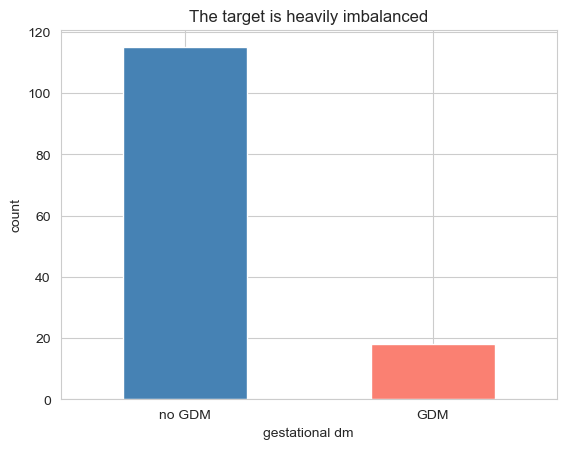

In [19]:
# Coach answer
print(y.value_counts())
print(f"GDM rate: {y.mean() * 100:.1f}%")

y.value_counts().rename({0: "no GDM", 1: "GDM"}).plot(kind="bar", color=["steelblue", "salmon"])
plt.title("The target is heavily imbalanced")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()

### Exercise 10: Oversample and undersample

Impute `X` with the median (into `X_demo`) so the samplers have no gaps, then apply `RandomOverSampler` and `RandomUnderSampler` and print the class balance after each. What is the trade-off?

> *Note:* here we resample the whole set to see the effect. In Task 5 we resample the **training data only**, after the split, which is the correct place.

In [20]:
# Your turn


In [21]:
X_demo = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=X.columns)

over_X, over_y = random_oversample(X_demo, y, random_state=RANDOM_STATE)
under_X, under_y = random_undersample(X_demo, y, random_state=RANDOM_STATE)

print("Original :", y.value_counts().to_dict())
print("Oversampled :", pd.Series(over_y).value_counts().to_dict(), "->", len(over_y), "rows")
print("Undersampled:", pd.Series(under_y).value_counts().to_dict(), "->", len(under_y), "rows")
# Oversampling duplicates minority (GDM) rows up to the majority count: keeps all data but repeats
# cases. Undersampling drops majority rows to the minority count: balanced but throws away most of
# the data (here down to 36 rows), which is risky on an already small dataset.

Original : {0: 115, 1: 18}
Oversampled : {1: 115, 0: 115} -> 230 rows
Undersampled: {1: 18, 0: 18} -> 36 rows


<a id="task5"></a>
## Task 5: Normalization and standardization

The final task is to put the features on a common scale. The clean way to combine imputation, scaling and resampling is a **pipeline**, fitted on the training data only, so the median fill values and the scaler's statistics are learned from the training set (no peeking at the test set) and resampling is applied only while training.

### Exercise 11: Split the data (stratified)

Split `X` (the version that still has missing values, so the pipeline can handle them) and `y` into train and test sets with `test_size=0.25`, `random_state=RANDOM_STATE`, and `stratify=y` so both sets keep the ~14% GDM rate.

In [22]:
# Your turn


In [23]:
# Coach answer
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("GDM rate  train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

Train: (99, 10)  Test: (34, 10)
GDM rate  train: 0.131  test: 0.147


### Exercise 12: Build a leakage-safe preprocessing workflow

Combine imputation, scaling and resampling so everything is learned from the training data only. Build a scikit-learn `Pipeline` of median `SimpleImputer` + `StandardScaler`, fit it on the training data, then oversample the *transformed training data only* with `random_oversample`. The result (`X_res`, `y_res`) is the cleaned, scaled, rebalanced training set, ready to hand to any model.

> *Note:* scikit-learn's own `Pipeline` cannot hold a resampler as a step (that is exactly what `imbalanced-learn`'s pipeline adds), so we resample **after** the fitted preprocessing, on the training data only. The effect is identical and needs no extra library.

In [24]:
# Your turn


In [ ]:
# Impute + scale as a normal scikit-learn pipeline (both are transformers), fitted on train only
prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
X_train_prep = prep.fit_transform(X_train)          # fill values + scaler learned from train only

# Oversample the prepared TRAINING data only (no imbalanced-learn needed)
X_res, y_res = random_oversample(X_train_prep, y_train, random_state=RANDOM_STATE)
print("Preprocessing fitted on train:", X_train_prep.shape, "-> after oversampling:", X_res.shape)
print("Class balance after oversampling:", pd.Series(y_res).value_counts().to_dict())

<a id="wrap"></a>
## Wrap-up

You took the raw case-study file and made it model-ready by working through the five tasks:

| Task | What you did |
|---|---|
| 1. Assessment | Found missing values, a near-constant column, text-coded numbers, and an imbalanced target |
| 2. Missing data | Weighed drop vs impute and chose median imputation for the 22%-missing glucose |
| 3. Enrichment | Parsed gestational age to numeric weeks, built `pulse_pressure`, and dropped ID / near-constant / leaking outcome columns |
| 4. Imbalance | Compared over- and under-sampling for the ~14% GDM target |
| 5. Normalization | Split first, imputed and scaled with a pipeline fitted on training only, then oversampled the training data, leaving it model-ready |

**The one-line lesson:** preprocessing is a sequence of deliberate, defensible decisions, and doing them inside a split-aware workflow is what keeps any eventual model honest. The exact same workflow applies to a credit or fraud dataset.

Great job. You have completed an end-to-end preprocessing case study.